# Vornamen neugeborener Mädchen und Knaben mit Wohnsitz in der Stadt Zürich

**Beschreibung**

Alle nach Geschlecht und Geburtsjahr aggregierten Vornamen von Neugeborenen mit Wohnsitz in der Stadt Zürich.


Datum: 05.05.2025

**Dataset auf INTEG Datenkatalog**:  https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_vornamen_baby_od3700

**Dataset auf PROD Datenkatalog**:  https://data.stadt-zuerich.ch/dataset/bev_vornamen_baby_od3700

## Bemerkungen

keine


### Importiere die notwendigen Packages

In [1]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [2]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [3]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [4]:
#help(mypy_dv)
help(mypy_dl)

Help on module my_py_dataloading_functions:

NAME
    my_py_dataloading_functions

FUNCTIONS
    load_data(status, data_source, package_name, dataset_name, **kwargs)
        Diese Funktion importiert die gewünschten Daten je nach Status (Int/Prod) und Speicherort (Dropzone/Web) in Pandas ein.
        
        Parameter:
        - status (str): sind die Daten auf Integ ('int') oder auf Prod ('prod') zu beziehen? 
        - data_source (str): sind die Daten im Internet ('web'), LOSD ('ld') oder auf den Dropzones/Fileverzeichnis ('dropzone') zu beziehen?
        - package_name (str): Name des Packages. Dies entspricht dem Slug in der URL und auch dem Verzeichnisnamen auf der Dropzone. Z.B. 'bfs_bev_bildungsstand_seit1970_OD1002'
        - dataset_name (str): Name des Datensatzes (in CKAN der Ressource). z.B. "bev324od3242.csv"
        
        Optionale Parameter:
        - ckan_integ_url (str):  Pfad zur INT-Umgebung von CKAN. Default: 'https://data.integ.stadt-zuerich.ch/dataset/'
     

In [5]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [6]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [7]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [8]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [9]:
package_name = "bev_vornamen_baby_od3700"

#### Daten nach neuer Struktur importieren

In [10]:
data2betested = mypy_dl.load_data(
    status = 'prod'
    , data_source = 'web'
    , ckan_integ_harvester_name = "INT_DWH_"
    , package_name = package_name
    , dataset_name = "BEV370OD3700"      
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.stadt-zuerich.ch/dataset/bev_vornamen_baby_od3700/download/BEV370OD3700.csv


 **Überprüfe die Metadaten:**

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_vornamen_baby_od3700 

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/bev_vornamen_baby_od3700 

data_source: web


Berechne weitere Attribute falls notwendig

In [11]:
data2betested.columns
#data2betested.dtypes

Index(['StichtagDatJahr', 'Vorname', 'SexLang', 'AnzGebuWir'], dtype='object')

In [12]:
data2betested.head(2)

,StichtagDatJahr,Vorname,SexLang,AnzGebuWir
0,1993-01-01,Abarna,weiblich,1
1,1993-01-01,Abetare,weiblich,1


In [13]:
data2betested = ( 
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDat_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr_nbr = lambda x: x.StichtagDatJahr.dt.year,
        FirstLetter = lambda x: x.Vorname.astype(str).str[0],
        SecondLetter = lambda x: x.Vorname.astype(str).str[1],        
        FirstTwoLetters = lambda x: x.Vorname.str.slice(stop=2), 
        
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.head(6)

,StichtagDatJahr,Vorname,SexLang,AnzGebuWir,StichtagDat_str,Jahr_nbr,FirstLetter,SecondLetter,FirstTwoLetters
69583,2024-01-01,Zwi,männlich,1,2024-01-01,2024,Z,w,Zw
33756,2024-01-01,Jana,weiblich,2,2024-01-01,2024,J,a,Ja
33748,2024-01-01,Isla,weiblich,1,2024-01-01,2024,I,s,Is
33749,2024-01-01,Isra,weiblich,1,2024-01-01,2024,I,s,Is
33750,2024-01-01,Israa,weiblich,1,2024-01-01,2024,I,s,Is
33751,2024-01-01,Ita,weiblich,1,2024-01-01,2024,I,t,It


Minimales und maximales Jahr im Datensatz

In [14]:
data_max_date = str(max(data2betested.StichtagDatJahr).year)
data_min_date = str(min(data2betested.StichtagDatJahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1993 und ein Maximumjahr von 2024


### Einfache Datentests

In [15]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 69,584 rows (observations) and 9 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [16]:
data2betested.describe()

,StichtagDatJahr,AnzGebuWir,Jahr_nbr
count,69584,69584,69584
mean,2009-05-25 15:03:41.016325376,2,2009
min,1993-01-01 00:00:00,1,1993
25%,2002-01-01 00:00:00,1,2002
50%,2010-01-01 00:00:00,1,2010
75%,2017-01-01 00:00:00,2,2017
max,2024-01-01 00:00:00,32,2024
std,NaN,2,9


Welches sind die Namen ohne Werte bei Anzahl Hunden?

In [17]:
data2betested[np.isnan(data2betested.AnzGebuWir)]

,StichtagDatJahr,Vorname,SexLang,AnzGebuWir,StichtagDat_str,Jahr_nbr,FirstLetter,SecondLetter,FirstTwoLetters


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [18]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [19]:
data2betested.index.year.unique()

Index([1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024],
      dtype='int32', name='StichtagDatJahr')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [20]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number'))
except:
    print("No categorical data in dataset.")

,Vorname,SexLang,StichtagDat_str,FirstLetter,SecondLetter,FirstTwoLetters
count,69584,69584,69584,69584,69584,69584
unique,22264,2,32,43,51,542
top,Lou,männlich,2014-01-01,A,a,Ma
freq,54,35209,2505,9285,17029,3812


Beschreibe numerische Attribute

In [21]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,AnzGebuWir,Jahr_nbr
count,"69,584","69,584"
mean,2,"2,009"
std,2,9
min,1,"1,993"
25%,1,"2,002"
50%,1,"2,010"
75%,2,"2,017"
max,32,"2,024"


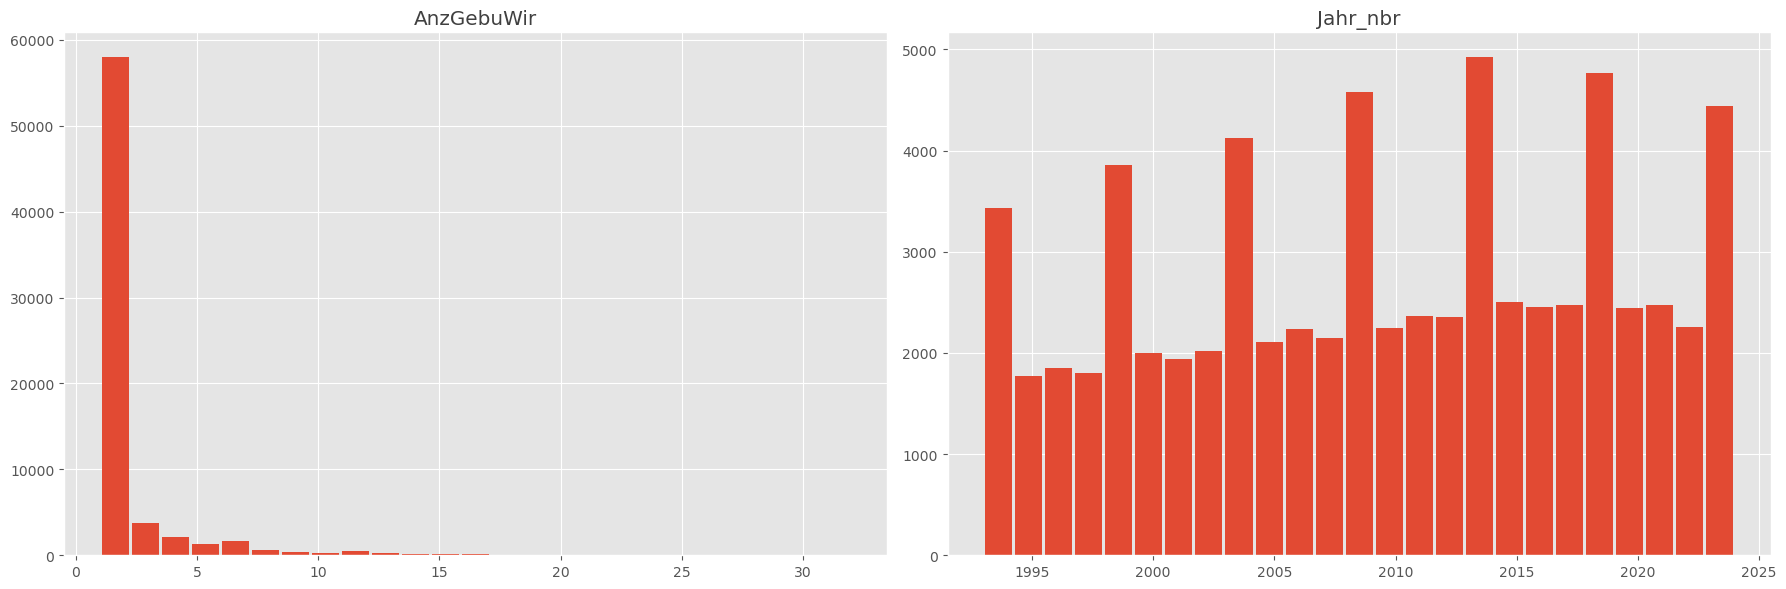

In [22]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [23]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows.sort_values(["Vorname", "StichtagDatJahr"], ascending=[True, False])

,Vorname,SexLang,AnzGebuWir,StichtagDat_str,Jahr_nbr,FirstLetter,SecondLetter,FirstTwoLetters
StichtagDatJahr,,,,,,,,


### Nullwerte und Missings?

In [24]:
data2betested.isnull().sum()

Vorname            0
SexLang            0
AnzGebuWir         0
StichtagDat_str    0
Jahr_nbr           0
FirstLetter        0
SecondLetter       0
FirstTwoLetters    0
dtype: int64

In [25]:
data2betested[['SecondLetter','Vorname']].loc[data_max_date].sort_values(['SecondLetter','Vorname'], ascending=[True, True])

,SecondLetter,Vorname
StichtagDatJahr,,
2024-01-01,a,Aaliyah
2024-01-01,a,Aalyia
2024-01-01,a,Aamo
2024-01-01,a,Aaren
2024-01-01,a,Aari
...,...,...
2024-01-01,ï,Aïda
2024-01-01,ú,Júlia
2024-01-01,ú,Lúan


In [26]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [27]:
agg_jahr = data2betested.loc[data_min_date:data_max_date].reset_index()\
    .groupby(['StichtagDatJahr', 'Jahr_nbr',]) \
    .agg(sum_AnzGeb=('AnzGebuWir', 'sum')) \
    .sort_values('Jahr_nbr', ascending=False) 
agg_jahr.reset_index().head(9)

,StichtagDatJahr,Jahr_nbr,sum_AnzGeb
0,2024-01-01,2024,4345
1,2023-01-01,2023,4475
2,2022-01-01,2022,4538
3,2021-01-01,2021,5261
4,2020-01-01,2020,5133
5,2019-01-01,2019,5134
6,2018-01-01,2018,5212
7,2017-01-01,2017,5240
8,2016-01-01,2016,5176


In [28]:
agg_name_sex = data2betested.loc[data_max_date]\
    .groupby(['Vorname','SexLang']) \
    .agg(sum_AnzGeb=('AnzGebuWir', 'sum')) \
    .sort_values('sum_AnzGeb', ascending=False) 
agg_name_sex.reset_index()

,Vorname,SexLang,sum_AnzGeb
0,Matteo,männlich,23
1,Emma,weiblich,23
2,Felix,männlich,21
3,Sofia,weiblich,20
4,Leonardo,männlich,20
...,...,...,...
2201,Ilay,männlich,1
2202,Ilan,männlich,1
2203,Ilaan,männlich,1
2204,Ignacy,männlich,1


In [29]:
fav_female_babynames = agg_name_sex.reset_index().query("SexLang=='weiblich' and sum_AnzGeb>1")

fav_female_babynames.reset_index()

,index,Vorname,SexLang,sum_AnzGeb
0,1,Emma,weiblich,23
1,3,Sofia,weiblich,20
2,6,Anna,weiblich,18
3,7,Ella,weiblich,18
4,10,Olivia,weiblich,18
...,...,...,...,...
305,651,Hayat,weiblich,2
306,652,Meret,weiblich,2
307,653,Mena,weiblich,2
308,654,Lilian,weiblich,2


In [30]:
fav_male_babynames = agg_name_sex.reset_index().query("SexLang!='weiblich' and sum_AnzGeb>1")

fav_male_babynames.reset_index()

,index,Vorname,SexLang,sum_AnzGeb
0,0,Matteo,männlich,23
1,2,Felix,männlich,21
2,4,Leonardo,männlich,20
3,5,Liam,männlich,18
4,8,Theo,männlich,18
...,...,...,...,...
343,643,Silvan,männlich,2
344,648,Bastian,männlich,2
345,649,Thiago,männlich,2
346,656,Siar,männlich,2


In [31]:
data2betested.columns

Index(['Vorname', 'SexLang', 'AnzGebuWir', 'StichtagDat_str', 'Jahr_nbr', 'FirstLetter',
       'SecondLetter', 'FirstTwoLetters'],
      dtype='object')

### Pivotiere

In [32]:
pivoted_df_vn_sex_jahr = data2betested.loc[data_min_date:data_max_date].pivot_table(
    index='Jahr_nbr',
    #columns=['Rasse1Text','Rasse2Text'],
    columns=['Vorname', 'SexLang'],
    values='AnzGebuWir',
    aggfunc='sum'
)

pivoted_df_vn_sex_jahr = pivoted_df_vn_sex_jahr.sort_values(by=pivoted_df_vn_sex_jahr.index[-1], axis=1, ascending=False)

# Sortieren der Zeilen (Jahre) in absteigender Reihenfolge
pivoted_df_vn_sex_jahr = pivoted_df_vn_sex_jahr.sort_index(ascending=False)

# Anzeigen des Ergebnisses
pivoted_df_vn_sex_jahr.head(12)


Vorname,Matteo,Emma,Felix,Sofia,Leonardo,Liam,Anna,...,Ümit,Ümran,Ümü,Šime,Šimon,Štefan,Šárka
SexLang,männlich,weiblich,männlich,weiblich,männlich,männlich,weiblich,...,männlich,weiblich,weiblich,männlich,männlich,männlich,weiblich
Jahr_nbr,,,,,,,,,,,,,,,
2024,23,23,21,20,20,18,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023,13,17,12,26,16,7,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022,10,14,12,16,13,16,21,...,1,NaN,NaN,NaN,NaN,1,1
2021,12,25,16,22,16,16,24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020,22,16,12,24,13,15,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019,13,11,21,25,13,11,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018,21,25,15,24,11,13,18,...,NaN,NaN,NaN,1,1,NaN,NaN
2017,17,28,20,24,14,28,23,...,NaN,NaN,NaN,NaN,1,NaN,NaN


In [33]:
pivoted_df_diff = pivoted_df_vn_sex_jahr.sort_index(ascending=True).diff()
pivoted_df_diff.tail(5)

Vorname,Matteo,Emma,Felix,Sofia,Leonardo,Liam,Anna,...,Ümit,Ümran,Ümü,Šime,Šimon,Štefan,Šárka
SexLang,männlich,weiblich,männlich,weiblich,männlich,männlich,weiblich,...,männlich,weiblich,weiblich,männlich,männlich,männlich,weiblich
Jahr_nbr,,,,,,,,,,,,,,,
2020,9,5,-9,-1,0,4,-4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021,-10,9,4,-2,3,1,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022,-2,-11,-4,-6,-3,0,-3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023,3,3,0,10,3,-9,-11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024,10,6,9,-6,4,11,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
similars = data2betested[data2betested['Vorname'].str.contains('rose', case=False, regex=True)]
similars['Vorname'].unique()

array(['Rosella', 'Rosemarie', 'Maria-Rose', 'Rose', 'Maryrose',
       'Rosemary', 'Rosewin', 'Amalia-Rose', 'Amy-Rose', 'Rosel',
       'Lilly-Rose', 'Jamaya Rose', 'Mina-Rose', 'Efthalia-Rosen',
       'Dinombrose', 'Vera-Rose', 'Amelia-Rose', 'Emma-Rose', 'Ambrose',
       'Rosenna', 'Dinah-Rose', 'Amaya-Rose', 'Roseli', 'Scarlett-Rose',
       'Zoey-Rose'], dtype=object)

### Visualisierungen nach Zeitausschnitten

#### Top Namen des aktuellen Jahres

In [35]:
fav_male_babynames.reset_index()

,index,Vorname,SexLang,sum_AnzGeb
0,0,Matteo,männlich,23
1,2,Felix,männlich,21
2,4,Leonardo,männlich,20
3,5,Liam,männlich,18
4,8,Theo,männlich,18
...,...,...,...,...
343,643,Silvan,männlich,2
344,648,Bastian,männlich,2
345,649,Thiago,männlich,2
346,656,Siar,männlich,2


In [36]:
fav_female_babynames

,Vorname,SexLang,sum_AnzGeb
1,Emma,weiblich,23
3,Sofia,weiblich,20
6,Anna,weiblich,18
7,Ella,weiblich,18
10,Olivia,weiblich,18
...,...,...,...
651,Hayat,weiblich,2
652,Meret,weiblich,2
653,Mena,weiblich,2
654,Lilian,weiblich,2


Top List for males

In [37]:
df_top_25_male = fav_male_babynames.sort_values('sum_AnzGeb', ascending=False).head(25)
df_top_5_male = fav_male_babynames.sort_values('sum_AnzGeb', ascending=False).head(5)
df_top_25_male.head(2)
#df_list_top_15_23 = top_15[['FzMarkeLang','sum_FzAnz']]
list_top_25_latest_year_male = df_top_25_male['Vorname'].tolist()
list_top_5_latest_year_male = df_top_5_male['Vorname'].tolist()

In [38]:
list_top_25_latest_year_male

['Matteo',
 'Felix',
 'Leonardo',
 'Liam',
 'Theo',
 'Emil',
 'Arthur',
 'Noah',
 'Elio',
 'Louis',
 'Luca',
 'Miro',
 'Levi',
 'Elias',
 'Alexander',
 'Nico',
 'Luis',
 'Rafael',
 'David',
 'Leon',
 'Oskar',
 'Max',
 'Jan',
 'Leo',
 'Oliver']

Top List for females

In [39]:
df_top_25_female = fav_female_babynames.sort_values('sum_AnzGeb', ascending=False).head(25)
df_top_5_female = fav_female_babynames.sort_values('sum_AnzGeb', ascending=False).head(5)
df_top_25_female.head(2)
#df_list_top_15_23 = top_15[['FzMarkeLang','sum_FzAnz']]
list_top_25_latest_year_female = df_top_25_female['Vorname'].tolist()
list_top_5_latest_year_female = df_top_5_female['Vorname'].tolist()

In [40]:
list_top_25_latest_year_female

['Emma',
 'Sofia',
 'Anna',
 'Ella',
 'Olivia',
 'Emilia',
 'Zoe',
 'Maria',
 'Elena',
 'Nora',
 'Mila',
 'Lara',
 'Lea',
 'Mia',
 'Sophia',
 'Maya',
 'Giulia',
 'Amelia',
 'Matilda',
 'Nina',
 'Anouk',
 'Mara',
 'Aria',
 'Ava',
 'Inaya']

Top List for all

In [41]:
agg_name_sex.reset_index()

,Vorname,SexLang,sum_AnzGeb
0,Matteo,männlich,23
1,Emma,weiblich,23
2,Felix,männlich,21
3,Sofia,weiblich,20
4,Leonardo,männlich,20
...,...,...,...
2201,Ilay,männlich,1
2202,Ilan,männlich,1
2203,Ilaan,männlich,1
2204,Ignacy,männlich,1


Wähle aus dem nach Jahr aggregierten Dataframe nur jene aus der Top25-Liste aus

In [42]:
data2betested.columns

Index(['Vorname', 'SexLang', 'AnzGebuWir', 'StichtagDat_str', 'Jahr_nbr', 'FirstLetter',
       'SecondLetter', 'FirstTwoLetters'],
      dtype='object')

In [43]:
#agg_name_sex.reset_index()
agg_name_sex_alltime = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr','Jahr_nbr','Vorname','SexLang']) \
    .agg(sum_AnzGeb=('AnzGebuWir', 'sum')) \
    .sort_values('sum_AnzGeb', ascending=False) 
agg_name_sex_alltime.reset_index()

,StichtagDatJahr,Jahr_nbr,Vorname,SexLang,sum_AnzGeb
0,2014-01-01,2014,Emma,weiblich,32
1,1998-01-01,1998,Laura,weiblich,31
2,2013-01-01,2013,Anna,weiblich,31
3,1993-01-01,1993,Laura,weiblich,31
4,2016-01-01,2016,Louis,männlich,30
...,...,...,...,...,...
69579,2006-01-01,2006,Rosalie,weiblich,1
69580,2006-01-01,2006,Rosani,weiblich,1
69581,2006-01-01,2006,Rosanna,weiblich,1
69582,2006-01-01,2006,Rosewin,männlich,1


In [44]:
df_sel_top25_male_beginning = data2betested.reset_index().query('Vorname in @list_top_25_latest_year_male')
df_sel_top5_male_beginning= data2betested.reset_index().query('Vorname in @list_top_5_latest_year_male')

df_sel_top25_female_beginning = data2betested.reset_index().query('Vorname in @list_top_25_latest_year_female')
df_sel_top5_female_beginning = data2betested.reset_index().query('Vorname in @list_top_5_latest_year_female')

#df_sel_top25_beginning = data2betested.reset_index().query('Vorname in @list_top_25_latest_year_all')
#df_sel_top5_beginning = data2betested.reset_index().query('Vorname in @list_top_5_latest_year_all')

In [45]:
df_sel_top25_male_beginning.head(5)

,StichtagDatJahr,Vorname,SexLang,AnzGebuWir,StichtagDat_str,Jahr_nbr,FirstLetter,SecondLetter,FirstTwoLetters
868,1993-01-01,Alexander,männlich,13,1993-01-01,1993,A,l,Al
917,1993-01-01,Arthur,männlich,1,1993-01-01,1993,A,r,Ar
1012,1993-01-01,David,männlich,19,1993-01-01,1993,D,a,Da
1068,1993-01-01,Elias,männlich,3,1993-01-01,1993,E,l,El
1091,1993-01-01,Felix,männlich,4,1993-01-01,1993,F,e,Fe


In [46]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = df_sel_top5_female_beginning.reset_index().sort_values('Vorname', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'AnzGebuWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Babies'
    ,category = "Vorname:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Top-5 Mädchen-Babynamen von "+data_max_date+", seit "+data_min_date
)
grafik1

alt.LayerChart(...)

In [47]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = df_sel_top5_male_beginning.reset_index().sort_values('Vorname', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'AnzGebuWir:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Babies'
    ,category = "Vorname:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Top-5 Knaben-Babynamen von "+data_max_date+", seit "+data_min_date
)
grafik2

alt.LayerChart(...)

#### Barcharts mit Seaborn

##### Entwicklung ...

In [48]:
df_sel_top25_male_beginning.columns

Index(['StichtagDatJahr', 'Vorname', 'SexLang', 'AnzGebuWir', 'StichtagDat_str', 'Jahr_nbr',
       'FirstLetter', 'SecondLetter', 'FirstTwoLetters'],
      dtype='object')

In [49]:
myAggBarMale = df_sel_top25_male_beginning.sort_values('AnzGebuWir', ascending=False)
myAggBarFemale = df_sel_top25_female_beginning.sort_values('AnzGebuWir', ascending=False)

In [50]:
#help(sns.catplot)   
# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")


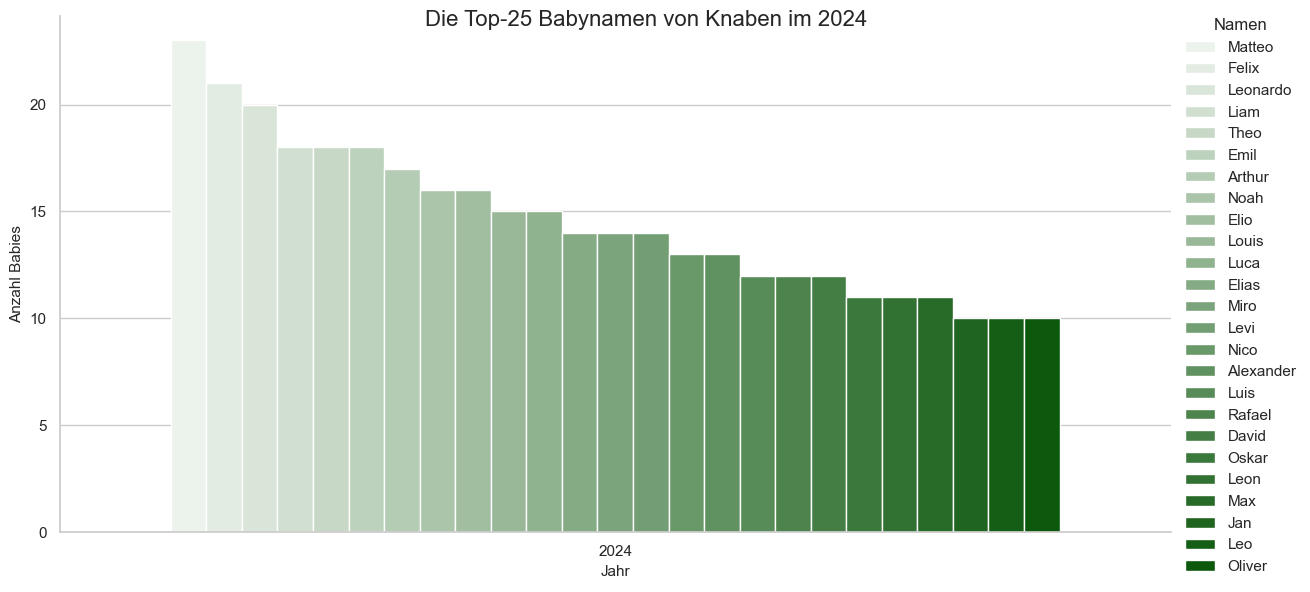

In [51]:
myHist = sns.catplot(x="Jahr_nbr"
            , y="AnzGebuWir"
            , hue="Vorname"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , color="darkgreen" # "cubehelix", "rocket", "pastel", color="green" 
            , height=6
            , aspect=2
            , order=None, legend_out=True
            ,data=myAggBarMale.query("StichtagDatJahr ==" +data_max_date).reset_index()
           )
myHist.set_xlabels('Jahr', fontsize=11) # not set_label
myHist.set_ylabels('Anzahl Babies', fontsize=11)

# Titel hinzufügen
myHist.fig.suptitle('Die Top-25 Babynamen von Knaben im '+data_max_date, fontsize=16)
# Legende anpassen
myHist.legend.set_title('Namen')
# Layout anpassen
#plt.tight_layout()
# Plot anzeigen
plt.show()

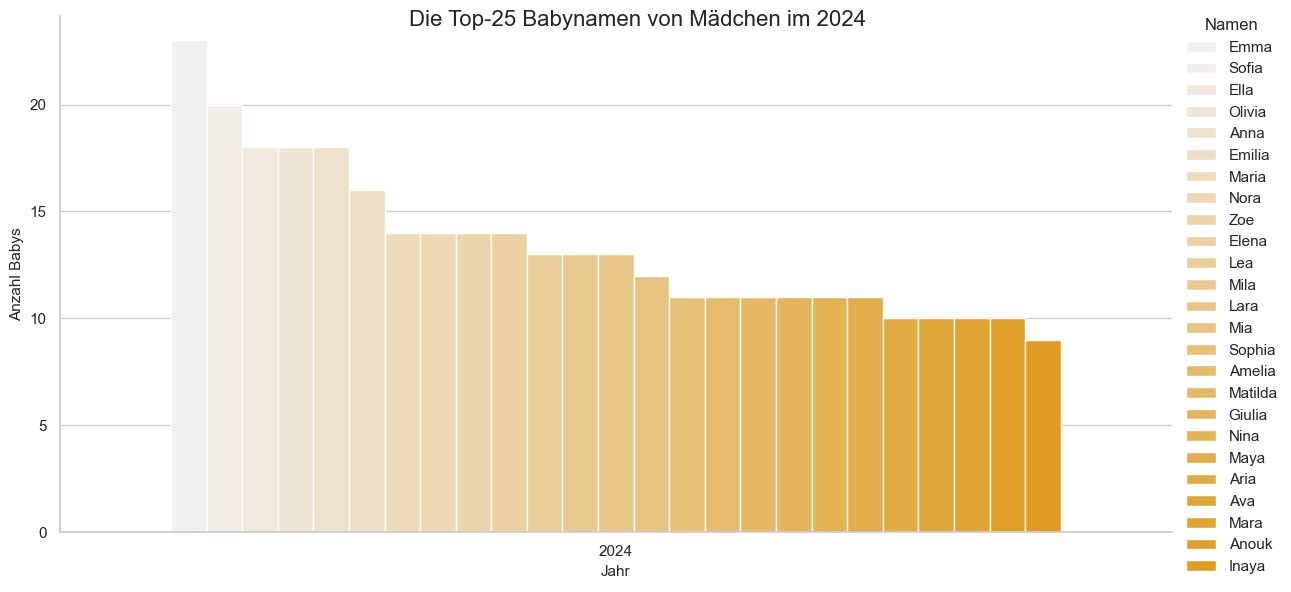

In [54]:
myHist = sns.catplot(x="Jahr_nbr"
            , y="AnzGebuWir"
            , hue="Vorname"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , color="orange" # "cubehelix", "rocket", "pastel", color="green" 
            , height=6
            , aspect=2
            , order=None, legend_out=True
            ,data=myAggBarFemale.query("StichtagDatJahr ==" +data_max_date).reset_index()
           )
myHist.set_xlabels('Jahr', fontsize=11) # not set_label
myHist.set_ylabels('Anzahl Babys', fontsize=11)

# Titel hinzufügen
myHist.fig.suptitle('Die Top-25 Babynamen von Mädchen im '+data_max_date, fontsize=16)
# Legende anpassen
myHist.legend.set_title('Namen')
# Layout anpassen
#plt.tight_layout()
# Plot anzeigen
plt.show()

--- stopped here

In [53]:
# Daten vorbereiten (angenommen, myAggBar ist Ihr DataFrame)
myAggBar = df_sel_top5_male_beginning

data = myAggBar.query("SexHundCd==1 and sum_AnzHunde > 0").reset_index()
data_pivoted = data.pivot(index='Jahr_nbr', columns='HundenameText', values='sum_AnzHunde').fillna(0)

# Farbpalette erstellen
colors = sns.color_palette("cubehelix", n_colors=len(data_pivoted.columns)) #"flare" / "vlag" / "icefire" / "Spectral"
# Figur und Achsen erstellen
fig, ax = plt.subplots(figsize=(12, 6))
# Gestapeltes Balkendiagramm zeichnen
data_pivoted.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=colors,
    width=0.9
    )
# Titel hinzufügen
plt.title('Entwicklung der Top-5 Hunderassen von '+data_max_date+' seit '+data_min_date, fontsize=14)
# Achsenbeschriftungen anpassen
ax.set_xlabel('Jahr', fontsize=11)
ax.set_ylabel('Anzahl Hunde', fontsize=11)

# Legende anpassen
plt.legend(title='Marke', bbox_to_anchor=(1.05, 1), loc='upper left')
# Layout anpassen
plt.tight_layout()
# Diagramm anzeigen
plt.show()

UndefinedVariableError: name 'SexHundCd' is not defined

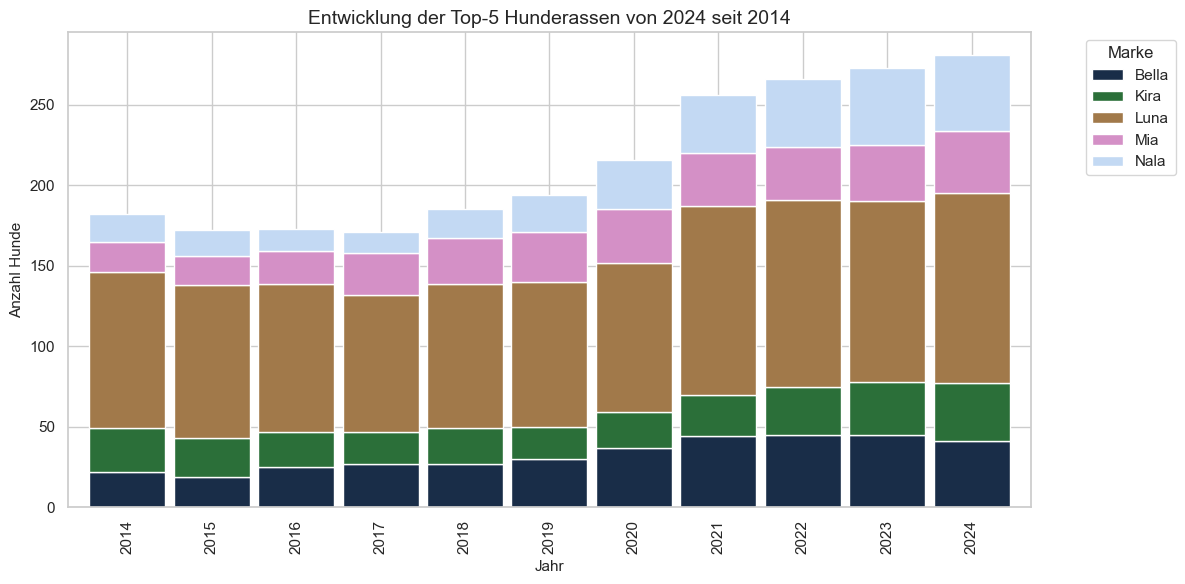

In [ ]:
# Daten vorbereiten (angenommen, myAggBar ist Ihr DataFrame)
myAggBar = df_sel_top5_female_since20015

data = myAggBar.query("SexHundCd==2 and sum_AnzHunde > 0").reset_index()
data_pivoted = data.pivot(index='Jahr_nbr', columns='HundenameText', values='sum_AnzHunde').fillna(0)

# Farbpalette erstellen
colors = sns.color_palette("cubehelix", n_colors=len(data_pivoted.columns)) #"flare" / "vlag" / "icefire" / "Spectral"
# Figur und Achsen erstellen
fig, ax = plt.subplots(figsize=(12, 6))
# Gestapeltes Balkendiagramm zeichnen
data_pivoted.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=colors,
    width=0.9
    )
# Titel hinzufügen
plt.title('Entwicklung der Top-5 Hunderassen von '+data_max_date+' seit '+data_min_date, fontsize=14)
# Achsenbeschriftungen anpassen
ax.set_xlabel('Jahr', fontsize=11)
ax.set_ylabel('Anzahl Hunde', fontsize=11)

# Legende anpassen
plt.legend(title='Marke', bbox_to_anchor=(1.05, 1), loc='upper left')
# Layout anpassen
plt.tight_layout()
# Diagramm anzeigen
plt.show()

#### Faced Grids

In [ ]:
data2betested.columns


Index(['StichtagDatJahr', 'StichtagDatMM', 'DatenstandCd', 'HundenameText', 'GebHundDatJahr',
       'SexHundCd', 'SexHundLang', 'SexHundSort', 'AnzHunde', 'StichtagDat_str', 'Jahr_nbr',
       'Monat_nbr', 'Monat_spoken', 'FirstLetter', 'SecondLetter', 'FirstTwoLetters'],
      dtype='object')

In [ ]:
myFG = data2betested.loc[data_min_date:"2024"]\
    .query('HundenameText in @list_top_5_latest_year')\
    .groupby(['Jahr_nbr', 'SexHundLang', 'SexHundSort','HundenameText']) \
    .agg(sum_AnzHunde=('AnzHunde', 'sum')) \
    .sort_values('SexHundSort', ascending=True) 

myFG.reset_index().head(3)

,Jahr_nbr,SexHundLang,SexHundSort,HundenameText,sum_AnzHunde
0,2014,männlich,1,Leo,28
1,2018,männlich,1,Leo,35
2,2018,männlich,1,Rocky,37


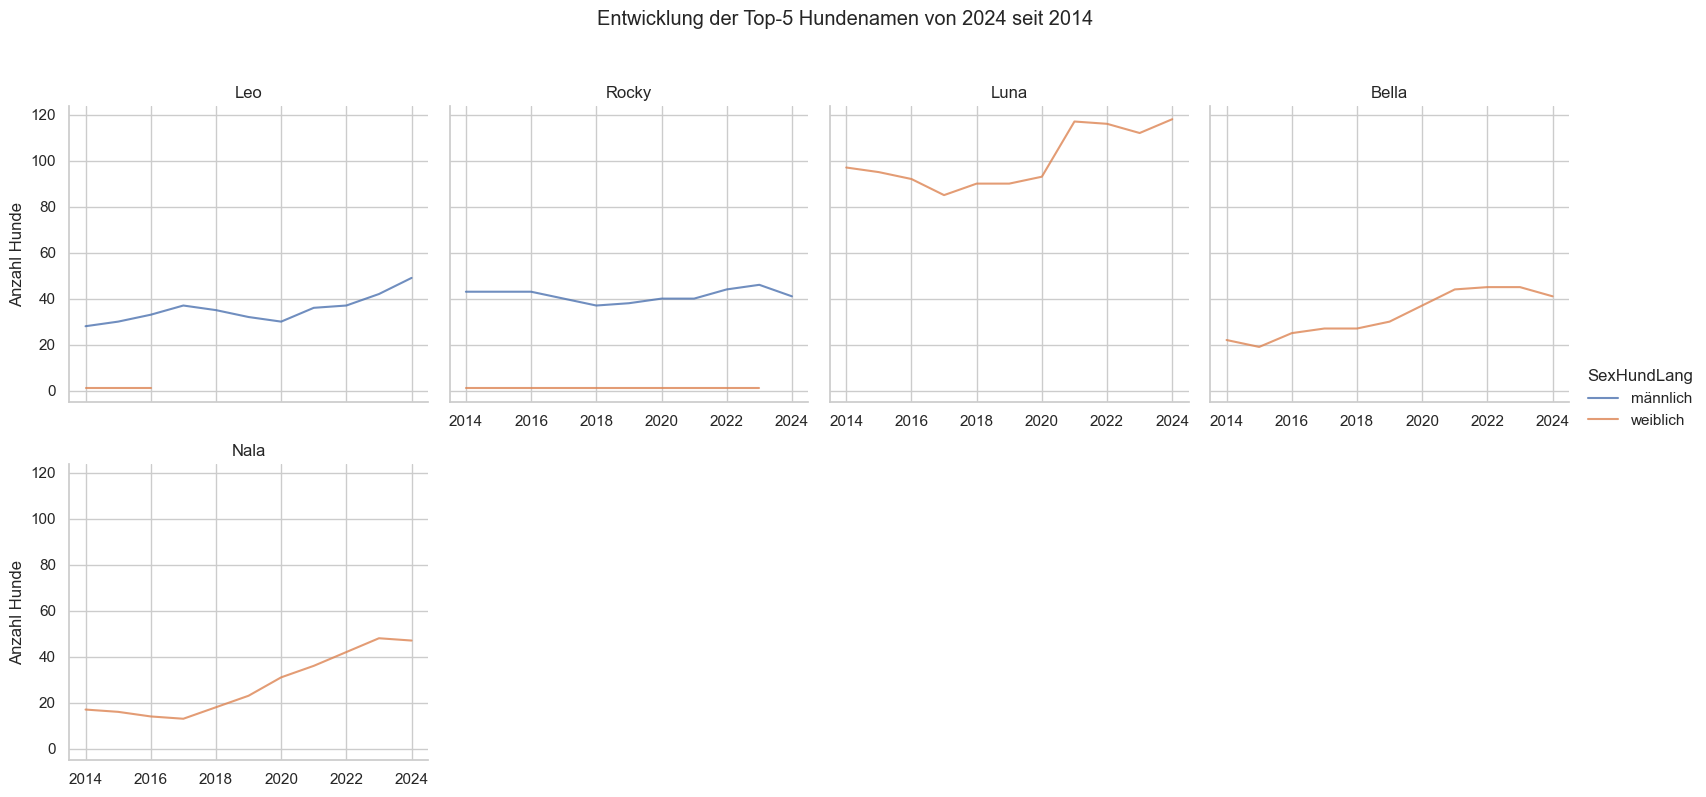

In [ ]:
faced_grid = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('SexHundSort', ascending=True)
    ,col = "HundenameText"
    ,hue = "SexHundLang"
    ,col_wrap = 4
    ,grafiktyp = sns.lineplot
    ,x = "Jahr_nbr"
    ,y = "sum_AnzHunde"
    ,ylabel= "Anzahl Hunde"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Entwicklung der Top-5 Hundenamen von "+data_max_date+' seit '+data_min_date
)
faced_grid

In [ ]:
list_top_25_latest_year

['Luna',
 'Leo',
 'Nala',
 'Rocky',
 'Bella',
 'Milo',
 'Mia',
 'Kira',
 'Lola',
 'Coco',
 'Max',
 'Lilly',
 'Emma',
 'Simba',
 'Lucy',
 'Charlie',
 'Stella',
 'Balu',
 'Lucky',
 'Bobby',
 'Daisy',
 'Jack',
 'Snoopy',
 'Ella',
 'Jimmy']

In [ ]:
myFG1 = data2betested.loc[data_min_date:"2024"]\
    .query('HundenameText in @list_top_25_latest_year')\
    .groupby(['Jahr_nbr', 'SexHundLang', 'SexHundSort','HundenameText']) \
    .agg(sum_AnzHunde=('AnzHunde', 'sum')) \
    .sort_values('SexHundSort', ascending=True) 

myFG.reset_index().head(3)

myFG1.reset_index().head(3)

,Jahr_nbr,SexHundLang,SexHundSort,HundenameText,sum_AnzHunde
0,2014,männlich,1,Balu,12
1,2018,männlich,1,Coco,9
2,2018,männlich,1,Daisy,1


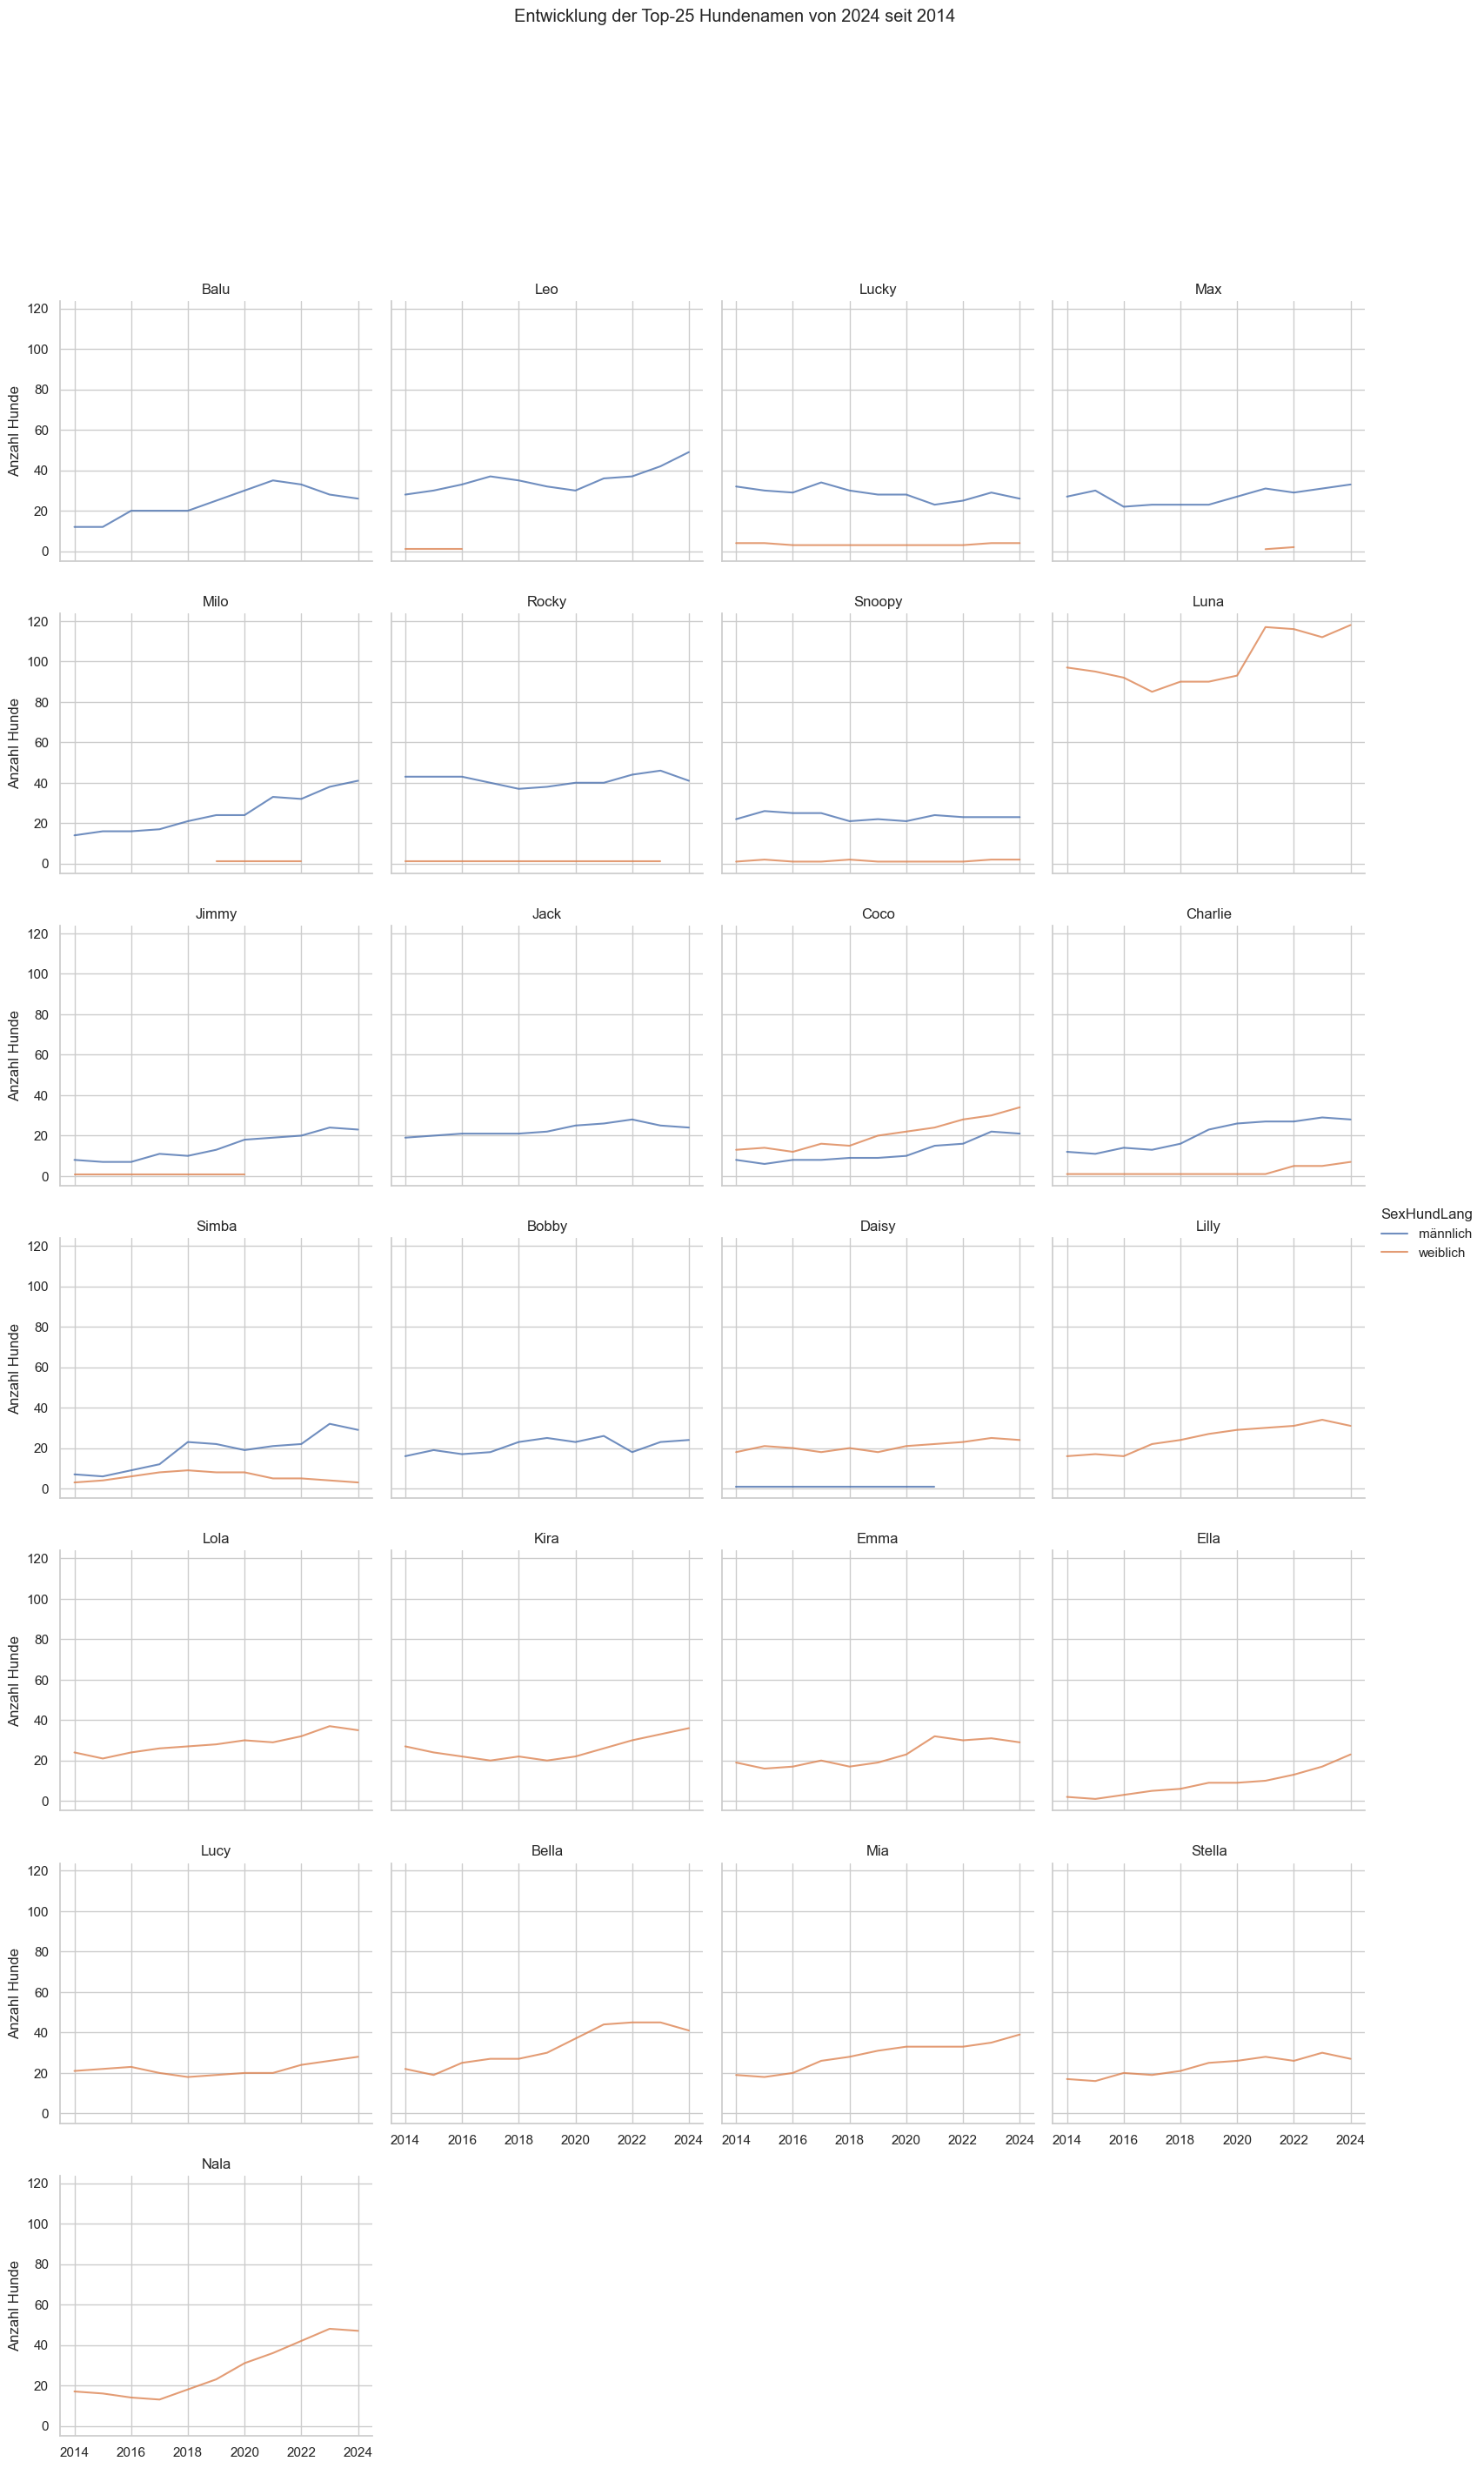

In [ ]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG1.reset_index().sort_values('SexHundSort', ascending=True)
    ,col = "HundenameText"
    ,hue = "SexHundLang"
    ,col_wrap = 4
    ,grafiktyp = sns.lineplot
    ,x = "Jahr_nbr"
    ,y = "sum_AnzHunde"
    ,ylabel= "Anzahl Hunde"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Entwicklung der Top-25 Hundenamen von "+data_max_date+' seit '+data_min_date
)
faced_grid1

In [ ]:
data2betested.columns

Index(['StichtagDatJahr', 'StichtagDatMM', 'DatenstandCd', 'HundenameText', 'GebHundDatJahr',
       'SexHundCd', 'SexHundLang', 'SexHundSort', 'AnzHunde', 'StichtagDat_str', 'Jahr_nbr',
       'Monat_nbr', 'Monat_spoken', 'FirstLetter', 'SecondLetter', 'FirstTwoLetters'],
      dtype='object')

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [ ]:
qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [ ]:
data2betested.columns

Index(['StichtagDatJahr', 'StichtagDatMM', 'DatenstandCd', 'HundenameText', 'GebHundDatJahr',
       'SexHundCd', 'SexHundLang', 'SexHundSort', 'AnzHunde', 'StichtagDat_str', 'Jahr_nbr',
       'Monat_nbr', 'Monat_spoken', 'FirstLetter', 'SecondLetter', 'FirstTwoLetters'],
      dtype='object')

In [ ]:
# Extrahiere die Top-Fahrzeugmarken
#attr2becolored = data2betested['FzMarkeLang'].unique().tolist()
attr2becolored = data2betested['FirstLetter']
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(attr2becolored):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'N': '#DB247D', 'F': '#99C32E', '?': '#5D4BFE', 'C': '#7B4FB7', 'B': '#9A5B01', 'A': '#DB247D', 'T': '#FBB900', '(': '#FFD736', 'G': '#349894', 'H': '#9A5B01', 'O': '#4AA9FF', 'P': '#1F9E31', 'R': '#9A5B01', 'Q': '#00A5D2', 'J': '#1F9E31', 'I': '#FF7231', 'S': '#A30059', 'D': '#3431DE', 'L': '#99C32E', 'K': '#007C78', 'V': '#5D4BFE', 'U': '#7B4FB7', 'W': '#0A8DF6', 'Z': '#FF720C', 'X': '#3431DE', 'Y': '#DA9C00', 's': '#FF919A', 'u': '#00615D', 'w': '#7B4100', 'M': '#007C78', 'E': '#23C3F1', "'": '#E4E0DF', 'l': '#DB247D', 'n': '#E4E0DF', '1': '#0072D7', 't': '#FFA8D0', 'p': '#7B4100', 'x': '#DA5563', 'É': '#5E359A', 'v': '#23C3F1', 'd': '#4AA9FF', 'f': '#23C3F1', '2': '#BA0062', 'g': '#44B14A', 'z': '#BA0062', 'a': '#986AD5', 'b': '#55BC5D', 'c': '#3431DE', 'e': '#00615D', 'y': '#FB737E', 'k': '#1F9E31', 'r': '#0A8DF6', 'm': '#986AD5', 'h': '#986AD5', 'j': '#FFD736'}


In [ ]:
myTreemapAgg = data2betested.loc[data_max_date]\
    .groupby(['Jahr_nbr', 'FirstLetter', 'FirstTwoLetters', 'HundenameText', 'SexHundCd', 'SexHundLang', 'SexHundSort',]) \
    .agg(sum_AnzHunde=('AnzHunde', 'sum')) \
    .sort_values('sum_AnzHunde', ascending=False)

myTreemapAgg = myTreemapAgg.reset_index().query("sum_AnzHunde > 4")
myTreemapAgg

,Jahr_nbr,FirstLetter,FirstTwoLetters,HundenameText,SexHundCd,SexHundLang,SexHundSort,sum_AnzHunde
0,2024,L,Lu,Luna,2,weiblich,2,118
1,2024,L,Le,Leo,1,männlich,1,49
2,2024,N,Na,Nala,2,weiblich,2,47
3,2024,R,Ro,Rocky,1,männlich,1,41
4,2024,B,Be,Bella,2,weiblich,2,41
...,...,...,...,...,...,...,...,...
290,2024,A,Ak,Akiro,1,männlich,1,5
291,2024,S,Sc,Scooby,1,männlich,1,5
292,2024,B,Br,Brownie,1,männlich,1,5
293,2024,T,To,Toffee,2,weiblich,2,5


##### Hundenamen nach Geschlecht und Anfangsbuchstaben

In [ ]:
#data=data2betested.loc[(data2betested.index.year == 2004)| (data2betested.index.year == 2014) | (data2betested.index.year == 2024)].query("FzAnz>50")
treeMap0 = mypy_dv.plot_px_treemap(
    data=myTreemapAgg.reset_index()
    ,levels=['Jahr_nbr', 'SexHundLang', 'FirstLetter', 'FirstTwoLetters',  'HundenameText',]
    ,values="sum_AnzHunde"
    ,color="HundenameText"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Hundenamen nach Geschlecht, Stand: "+data_max_date
)
treeMap0

path: [<plotly.express._special_inputs.Constant object at 0x000001ABE92EFA10>, 'Jahr_nbr', 'SexHundLang', 'FirstLetter', 'FirstTwoLetters', 'HundenameText']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=524&e=4BCdeL)**

---------------------------------------------------------------------------

In [ ]:
typische_farben = {
    'Volkswagen': '#fe0000',  # VW-Blau
    'BMW': '#0059ff',  # BMW-Blau
    'Mercedes Benz': '#000056',  # Mercedes-Blau
    'Audi': '#000000',  # Audi-Schwarz
    'Skoda': '#228B22',  # Skoda-Grün
    'Toyota': '#CC0000',  # Toyota-Rot
    'Volvo': '#003057',  # Volvo-Blau
    'Renault': '#FFD100',  # Renault-Gelb
    'Ford': '#1C3E53',  # Ford-Blau
    'Fiat': '#6F0000',  # Fiat-Rot
    'Opel': '#FFC720',  # Opel-Gelb
    'Peugeot': '#1E448E',  # Peugeot-Blau
    'Seat': '#EB0000',  # Seat-Rot
    'Porsche': '#C8102E',  # Porsche-Rot
    'Mini': '#000000',  # Mini-Schwarz
    'Hyundai': '#005C9C',  # Hyundai-Blau
    'Nissan': '#E4002B',  # Nissan-Rot
    'Tesla': '#CC0000',  # Tesla-Rot
    'Citroen': '#F68E56',  # Citroen-Orange
    'Mazda': '#FF0000',  # Mazda-Rot
    'Land Rover': '#214136',  # Land Rover-Grün
    'Honda': '#E30012',  # Honda-Rot
    'Smart': '#009CDF',  # Smart-Blau
    'Alfa Romeo': '#B30000',  # Alfa Romeo-Rot
    'Subaru': '#1C3E53',  # Subaru-Blau
    'Kia': '#0082C9',  # Kia-Blau
    'Suzuki': '#E30613',  # Suzuki-Rot
    'Mitsubishi': '#E60012',  # Mitsubishi-Rot
    'Jaguar': '#1C1B1B',  # Jaguar-Schwarz
    'Jeep': '#004C6C',  # Jeep-Blau
    'Dacia': '#00205E',  # Dacia-Blau
    'Andere': '#808080',  # Grau
    'Saab': '#CC0000',  # Saab-Rot
    'Lexus': '#660099',  # Lexus-Lila
    'Chevrolet': '#C8102E',  # Chevrolet-Rot
    'Lancia': '#1E448E',  # Lancia-Blau
    'Maserati': '#98002E',  # Maserati-Rot
    'Ferrari': '#DC0000',  # Ferrari-Rot
    'Daihatsu': '#0066CC',  # Daihatsu-Blau
    'Chrysler': '#001489',  # Chrysler-Blau
    'Bentley': '#000A12',  # Bentley-Schwarz
    'Aston Martin': '#2B2B2B',  # Aston Martin-Grau
    'AMG': '#000000',  # AMG-Schwarz
    'Dodge': '#C8102E',  # Dodge-Rot
    'MG': '#CC0000',  # MG-Rot
    'Cadillac': '#1E448E',  # Cadillac-Blau
    'Weinsberg': '#0085C0',  # Weinsberg-Blau
    'Lotus': '#FF0000',  # Lotus-Rot
    'Rolls Royce': '#680018',  # Rolls Royce-Burgunderrot
    'Unbekannt': '#B3B3B3',  # Hellgrau
    'Triumph': '#2B2B2B',  # Triumph-Grau
    'SsangYong': '#005E2B',  # SsangYong-Grün
    'Rover': '#045481'  # Rover-Blau
}

# Extrahiere die Top-Fahrzeugmarken
top_fahrzeugmarken = agg_marke_years.reset_index().query('sum_FzAnz > 50')['FzMarkeLang'].tolist()

# Beispiel-Code für die Verwendung in deiner Treemap
farben_dict = {'(?)':'lightgrey', 'Quartier':'lightgrey'}
for marke in top_fahrzeugmarken:
    #print(farben_dict)
    if marke in typische_farben:
        farben_dict[marke] = typische_farben[marke]
    else:
        farben_dict[marke] = '#808080'  # Standardfarbe für unbekannte Marken

NameError: name 'agg_marke_years' is not defined